# 🩺 Analyse et Prédiction du Diabète
## Projet de Machine Learning avec Random Forest

Ce notebook présente une analyse complète du dataset de diabète et l'entraînement d'un modèle de classification pour prédire le risque de diabète.

**Auteur:** Diabetes AI Project  
**Date:** Février 2026  
**Modèle:** Random Forest Classifier

## 📚 1. Import des Bibliothèques

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np
from pathlib import Path

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    roc_curve,
    roc_auc_score
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sauvegarde du modèle
import joblib

# Configuration d'affichage
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Toutes les bibliothèques sont importées avec succès!")

✓ Toutes les bibliothèques sont importées avec succès!


## 📁 2. Configuration des Chemins

In [2]:
# Définir les chemins
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = BASE_DIR / "data" / "diabetes_dataset_generated.csv"
MODELS_DIR = BASE_DIR / "models"
MODEL_PATH = MODELS_DIR / "model.pkl"
SCALER_PATH = MODELS_DIR / "scaler.pkl"

# Créer le dossier models s'il n'existe pas
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Répertoire de base : {BASE_DIR}")
print(f"📊 Dataset : {DATA_PATH}")
print(f"💾 Modèle sera sauvegardé dans : {MODELS_DIR}")

📂 Répertoire de base : c:\Users\pc\Desktop\ML\diabetes_ai_web\backend
📊 Dataset : c:\Users\pc\Desktop\ML\diabetes_ai_web\backend\data\diabetes_dataset_generated.csv
💾 Modèle sera sauvegardé dans : c:\Users\pc\Desktop\ML\diabetes_ai_web\backend\models


## 📊 3. Chargement et Exploration des Données

In [3]:
# Charger le dataset
df = pd.read_csv(DATA_PATH)

print(f"✓ Dataset chargé avec succès!")
print(f"\n📏 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📋 Colonnes du dataset :")
print(df.columns.tolist())

✓ Dataset chargé avec succès!

📏 Dimensions : 1000 lignes × 9 colonnes

📋 Colonnes du dataset :
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [4]:
# Afficher les premières lignes
print("🔍 Aperçu des premières lignes du dataset :\n")
df.head(10)

🔍 Aperçu des premières lignes du dataset :



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,146,89,28,69,43.0,1.603,26,1
1,3,91,66,22,98,40.8,2.239,79,1
2,7,93,81,23,65,28.1,1.314,76,0
3,4,126,61,25,180,32.4,0.285,79,1
4,6,101,66,23,111,30.3,0.835,67,1
5,9,159,60,32,83,32.8,1.674,45,1
6,2,101,44,11,92,33.6,0.674,79,1
7,6,105,69,21,96,35.2,0.773,71,1
8,7,132,71,5,97,14.6,2.069,70,0
9,4,108,82,3,70,34.2,1.502,24,0


In [5]:
# Informations sur le dataset
print("ℹ️ Informations sur le dataset :\n")
df.info()

ℹ️ Informations sur le dataset :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   int64  
 2   BloodPressure             1000 non-null   int64  
 3   SkinThickness             1000 non-null   int64  
 4   Insulin                   1000 non-null   int64  
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   int64  
 8   Outcome                   1000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 70.4 KB


In [6]:
# Statistiques descriptives
print("📈 Statistiques descriptives :\n")
df.describe()

📈 Statistiques descriptives :



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,4.448000,119.818000,70.360000,19.373000,80.49900,32.009600,1.337186,50.352000,0.50000
std,2.912005,30.726063,12.511952,7.748543,37.91313,6.007175,0.692008,17.135452,0.50025
min,0.000000,12.000000,35.000000,0.000000,0.00000,9.700000,0.113000,21.000000,0.00000
25%,2.000000,100.000000,62.000000,14.000000,54.00000,27.900000,0.752750,36.000000,0.00000
50%,4.000000,120.000000,71.000000,19.500000,79.00000,32.200000,1.360000,49.000000,0.50000
75%,7.000000,141.000000,79.000000,25.000000,105.00000,36.200000,1.950500,65.000000,1.00000
max,9.000000,214.000000,109.000000,42.000000,226.00000,49.000000,2.499000,79.000000,1.00000


## 🧹 4. Nettoyage des Données

In [7]:
# Vérifier les valeurs manquantes
print("🔍 Valeurs manquantes par colonne :\n")
null_counts = df.isnull().sum()
print(null_counts)

# Supprimer les lignes avec valeurs null
df_original_size = df.shape[0]
df_cleaned = df.dropna()
removed_rows = df_original_size - df_cleaned.shape[0]

print(f"\n✓ Lignes avec valeurs null supprimées : {removed_rows}")
print(f"✓ Dataset nettoyé : {df_cleaned.shape[0]} lignes")

🔍 Valeurs manquantes par colonne :

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✓ Lignes avec valeurs null supprimées : 0
✓ Dataset nettoyé : 1000 lignes


## 📊 5. Visualisations Exploratoires

C:\Users\pc\AppData\Local\Temp\ipykernel_19380\2098088765.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


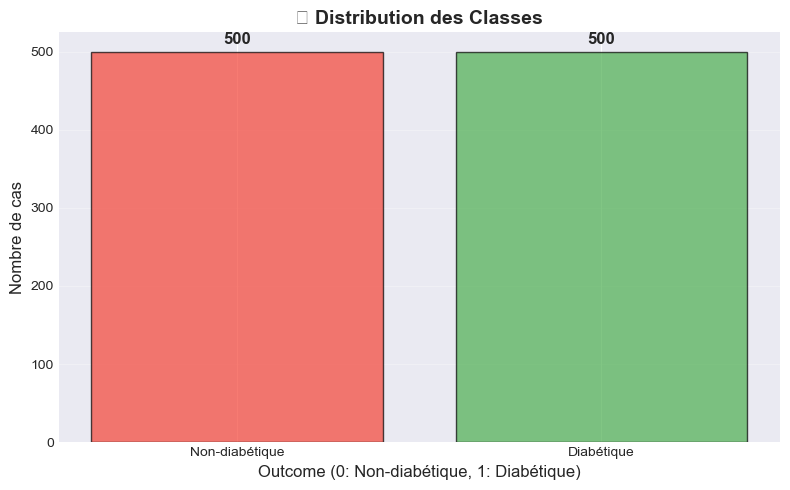

✓ Classes équilibrées : 500 non-diabétiques, 500 diabétiques


In [8]:
# Distribution de la variable cible
plt.figure(figsize=(8, 5))
outcome_counts = df_cleaned.iloc[:, -1].value_counts()
colors = ['#4CAF50', '#F44336']
plt.bar(outcome_counts.index, outcome_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Outcome (0: Non-diabétique, 1: Diabétique)', fontsize=12)
plt.ylabel('Nombre de cas', fontsize=12)
plt.title('📊 Distribution des Classes', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Non-diabétique', 'Diabétique'])
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(outcome_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"✓ Classes équilibrées : {outcome_counts[0]} non-diabétiques, {outcome_counts[1]} diabétiques")

C:\Users\pc\AppData\Local\Temp\ipykernel_19380\3515606279.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()


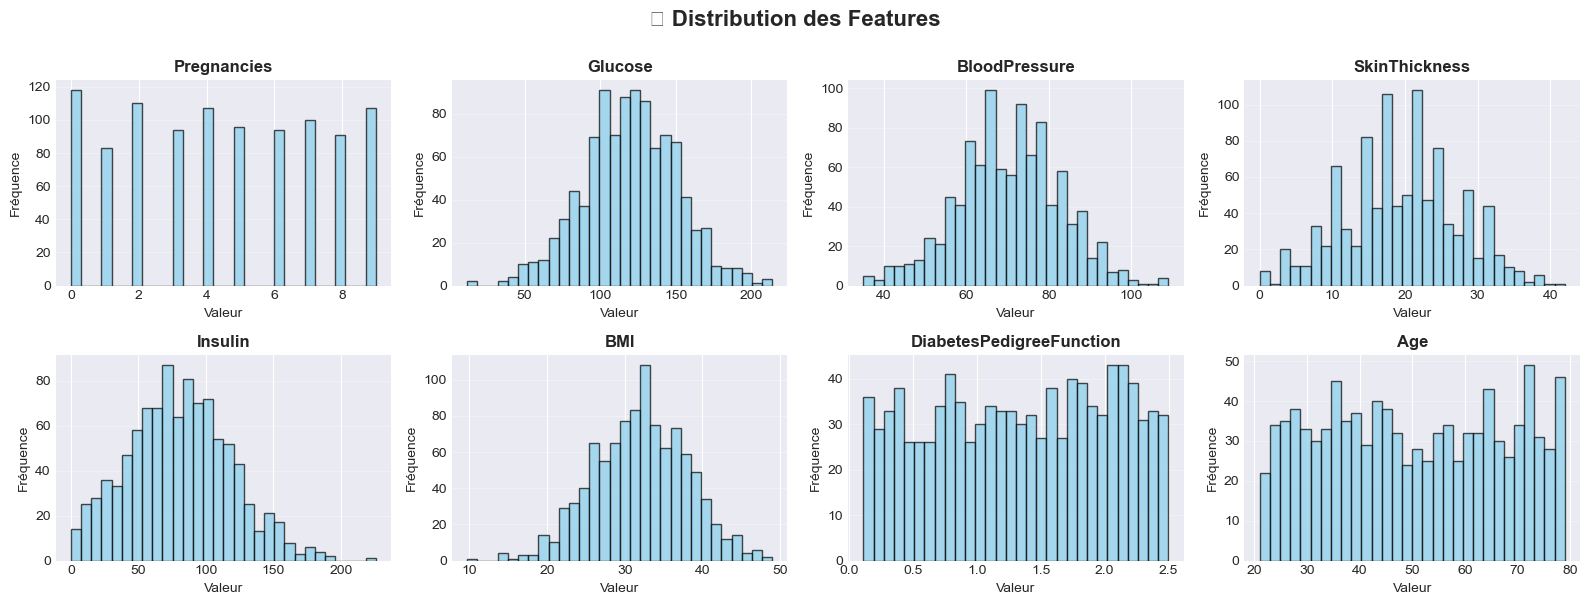

In [9]:
# Distribution des features numériques
feature_columns = df_cleaned.columns[:-1]
n_cols = 4
n_rows = (len(feature_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(feature_columns):
    axes[idx].hist(df_cleaned[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(axis='y', alpha=0.3)

# Masquer les axes inutilisés
for idx in range(len(feature_columns), len(axes)):
    axes[idx].axis('off')

plt.suptitle('📊 Distribution des Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_19380\1496867042.py:16: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


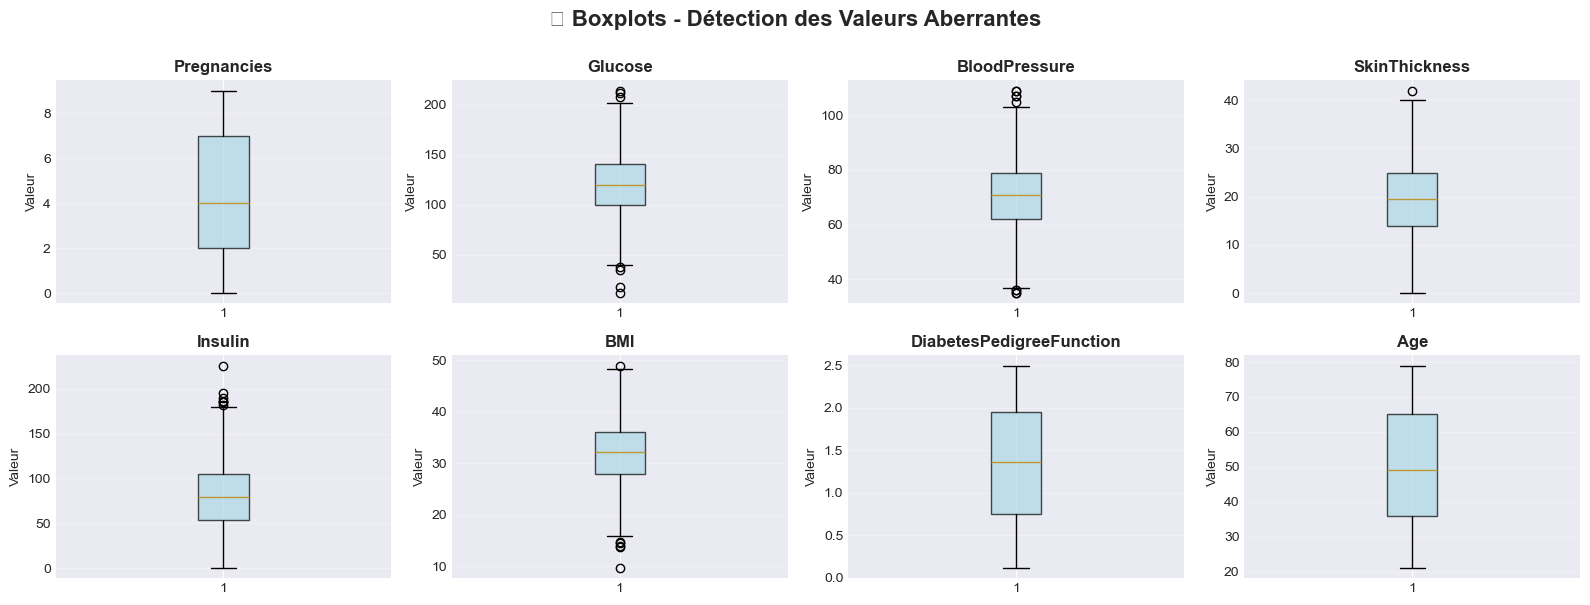

In [10]:
# Boxplots pour détecter les valeurs aberrantes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(feature_columns):
    axes[idx].boxplot(df_cleaned[col], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Valeur')
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(feature_columns), len(axes)):
    axes[idx].axis('off')

plt.suptitle('📦 Boxplots - Détection des Valeurs Aberrantes', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_19380\609897630.py:7: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


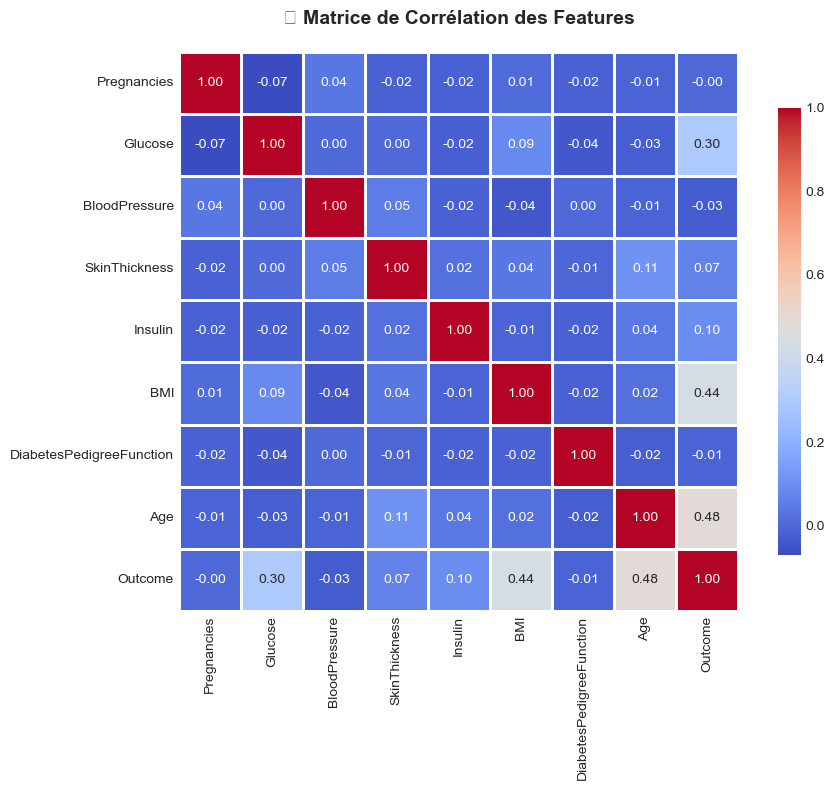


✓ Corrélations les plus fortes avec Outcome:
Age                         0.484852
BMI                         0.438095
Glucose                     0.300351
Insulin                     0.095028
SkinThickness               0.065723
BloodPressure               0.030066
DiabetesPedigreeFunction    0.007258
Pregnancies                 0.001374
Name: Outcome, dtype: float64


In [11]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('🔥 Matrice de Corrélation des Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Corrélations les plus fortes avec Outcome:")
target_corr = correlation_matrix.iloc[-1, :-1].abs().sort_values(ascending=False)
print(target_corr)

## ⚙️ 6. Préparation des Données pour l'Entraînement

In [12]:
# Séparer features et target
X = df_cleaned.iloc[:, :-1].values
y = df_cleaned.iloc[:, -1].values

print(f"✓ Features (X) : {X.shape}")
print(f"✓ Target (y) : {y.shape}")
print(f"\n✓ Distribution des classes : {np.bincount(y.astype(int))}")

✓ Features (X) : (1000, 8)
✓ Target (y) : (1000,)

✓ Distribution des classes : [500 500]


In [13]:
# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Données d'entraînement : {X_train.shape[0]} échantillons ({(X_train.shape[0]/X.shape[0])*100:.0f}%)")
print(f"📊 Données de test : {X_test.shape[0]} échantillons ({(X_test.shape[0]/X.shape[0])*100:.0f}%)")

📊 Données d'entraînement : 800 échantillons (80%)
📊 Données de test : 200 échantillons (20%)


## 🔄 7. Normalisation des Features

In [14]:
# Normaliser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Normalisation effectuée avec StandardScaler")
print(f"\nMoyenne des features (après scaling) : {X_train_scaled.mean(axis=0).round(2)}")
print(f"Écart-type des features (après scaling) : {X_train_scaled.std(axis=0).round(2)}")

✓ Normalisation effectuée avec StandardScaler

Moyenne des features (après scaling) : [ 0.  0.  0.  0. -0. -0. -0. -0.]
Écart-type des features (après scaling) : [1. 1. 1. 1. 1. 1. 1. 1.]


## 🤖 8. Entraînement du Modèle Random Forest

In [15]:
import time

# Initialiser et entraîner le modèle
print("🚀 Démarrage de l'entraînement du modèle Random Forest...\n")
start_time = time.time()

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✓ Entraînement terminé en {training_time:.2f} secondes")
print(f"✓ Nombre d'arbres : {model.n_estimators}")
print(f"✓ Profondeur maximale : {model.max_depth}")

🚀 Démarrage de l'entraînement du modèle Random Forest...


✓ Entraînement terminé en 0.67 secondes
✓ Nombre d'arbres : 200
✓ Profondeur maximale : 10


## 📈 9. Évaluation des Performances

In [16]:
# Prédictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calcul des précisions
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 60)
print("📊 RÉSULTATS DE PERFORMANCE")
print("=" * 60)
print(f"\n✓ Précision sur train : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"✓ Précision sur test  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Calculer l'overfitting
overfitting_percentage = ((train_accuracy - test_accuracy) / train_accuracy) * 100
print(f"\n⚠️  Écart train-test : {overfitting_percentage:.2f}%")

if overfitting_percentage < 5:
    print("✓ Bon équilibre - Pas de surapprentissage significatif")
elif overfitting_percentage < 10:
    print("⚠️ Léger surapprentissage - Acceptable")
else:
    print("❌ Surapprentissage important - Révision du modèle recommandée")

📊 RÉSULTATS DE PERFORMANCE

✓ Précision sur train : 1.0000 (100.00%)
✓ Précision sur test  : 0.9750 (97.50%)

⚠️  Écart train-test : 2.50%
✓ Bon équilibre - Pas de surapprentissage significatif


In [17]:
# Rapport de classification
print("\n" + "=" * 60)
print("📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("=" * 60 + "\n")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Non-diabétique', 'Diabétique'],
                          digits=4))


📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ

                precision    recall  f1-score   support

Non-diabétique     0.9612    0.9900    0.9754       100
    Diabétique     0.9897    0.9600    0.9746       100

      accuracy                         0.9750       200
     macro avg     0.9754    0.9750    0.9750       200
  weighted avg     0.9754    0.9750    0.9750       200



C:\Users\pc\AppData\Local\Temp\ipykernel_19380\3805825723.py:12: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


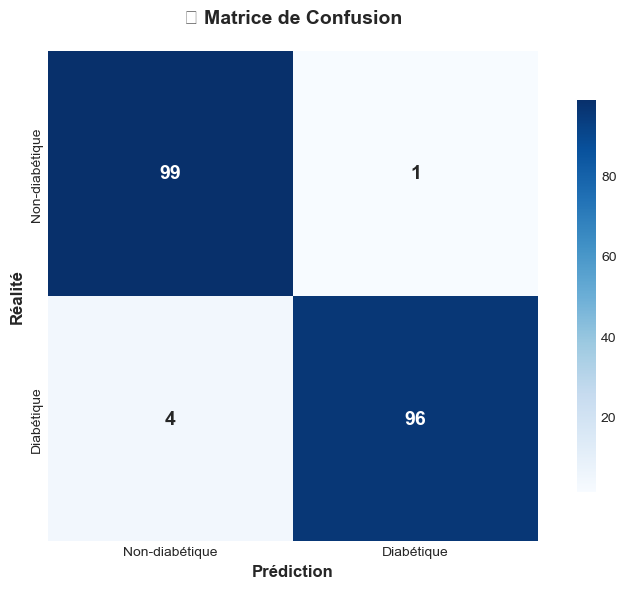


✓ Vrais Négatifs (TN) : 99
✓ Faux Positifs (FP) : 1
✓ Faux Négatifs (FN) : 4
✓ Vrais Positifs (TP) : 96


In [18]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non-diabétique', 'Diabétique'],
            yticklabels=['Non-diabétique', 'Diabétique'],
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 14, "weight": "bold"})
plt.xlabel('Prédiction', fontsize=12, fontweight='bold')
plt.ylabel('Réalité', fontsize=12, fontweight='bold')
plt.title('🎯 Matrice de Confusion', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Calculs détaillés
tn, fp, fn, tp = cm.ravel()
print(f"\n✓ Vrais Négatifs (TN) : {tn}")
print(f"✓ Faux Positifs (FP) : {fp}")
print(f"✓ Faux Négatifs (FN) : {fn}")
print(f"✓ Vrais Positifs (TP) : {tp}")

C:\Users\pc\AppData\Local\Temp\ipykernel_19380\687365307.py:16: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


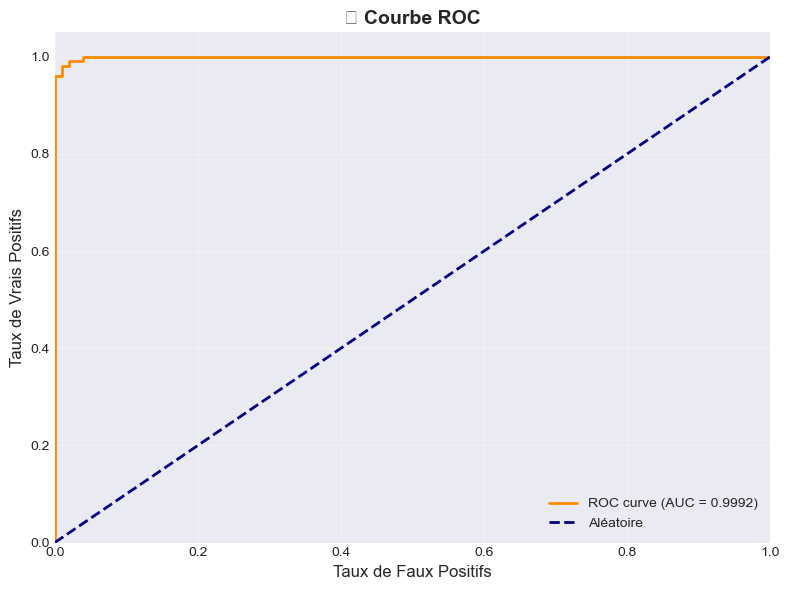

✓ Score AUC-ROC : 0.9992


In [19]:
# Courbe ROC
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('📉 Courbe ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Score AUC-ROC : {roc_auc:.4f}")

## 🎯 10. Importance des Features

✓ Importance des Features :

                 Feature  Importance
                     Age    0.342017
                     BMI    0.311970
                 Glucose    0.210467
                 Insulin    0.051399
DiabetesPedigreeFunction    0.026774
           BloodPressure    0.025545
           SkinThickness    0.018413
             Pregnancies    0.013416


C:\Users\pc\AppData\Local\Temp\ipykernel_19380\3283346094.py:20: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


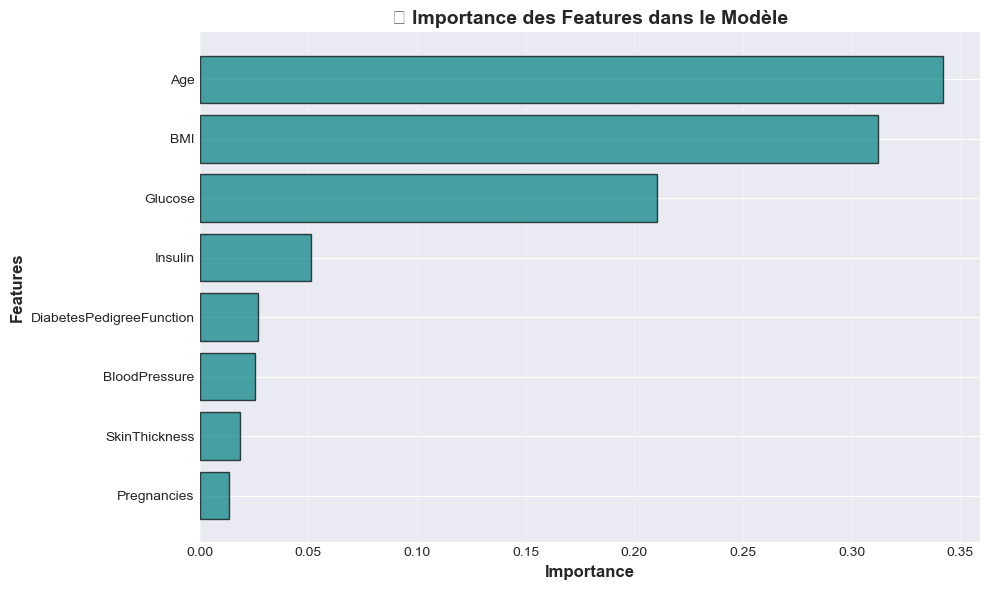

In [20]:
# Importance des features
feature_names = df_cleaned.columns[:-1].tolist()
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("✓ Importance des Features :\n")
print(feature_importance.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
         color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('🎯 Importance des Features dans le Modèle', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 💾 11. Sauvegarde du Modèle et du Scaler

In [21]:
# Sauvegarder le modèle et le scaler
joblib.dump(model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("=" * 60)
print("💾 SAUVEGARDE DES ARTIFACTS")
print("=" * 60)
print(f"\n✓ Modèle sauvegardé dans : {MODEL_PATH}")
print(f"✓ Scaler sauvegardé dans : {SCALER_PATH}")

# Vérifier les tailles de fichiers
model_size = MODEL_PATH.stat().st_size / 1024  # KB
scaler_size = SCALER_PATH.stat().st_size / 1024  # KB

print(f"\n📊 Taille du modèle : {model_size:.2f} KB")
print(f"📊 Taille du scaler : {scaler_size:.2f} KB")
print("\n🎉 Tous les artifacts ont été sauvegardés avec succès!")

💾 SAUVEGARDE DES ARTIFACTS

✓ Modèle sauvegardé dans : c:\Users\pc\Desktop\ML\diabetes_ai_web\backend\models\model.pkl
✓ Scaler sauvegardé dans : c:\Users\pc\Desktop\ML\diabetes_ai_web\backend\models\scaler.pkl

📊 Taille du modèle : 1204.04 KB
📊 Taille du scaler : 0.79 KB

🎉 Tous les artifacts ont été sauvegardés avec succès!


## ✅ 12. Résumé et Conclusions

In [22]:
print("=" * 70)
print("📊 RÉSUMÉ FINAL DE L'ANALYSE")
print("=" * 70)
print(f"\n📁 Dataset : {df_cleaned.shape[0]} échantillons, {df_cleaned.shape[1]} colonnes")
print(f"📊 Distribution : {outcome_counts[0]} non-diabétiques / {outcome_counts[1]} diabétiques")
print(f"\n🤖 Modèle : Random Forest avec {model.n_estimators} arbres")
print(f"⏱️  Temps d'entraînement : {training_time:.2f} secondes")
print(f"\n🎯 Performance sur test : {test_accuracy*100:.2f}%")
print(f"📈 Score AUC-ROC : {roc_auc:.4f}")
print(f"\n🏆 Top 3 features importantes :")
for idx, row in feature_importance.head(3).iterrows():
    print(f"   {row['Feature']:25s} : {row['Importance']:.4f}")
print("\n" + "=" * 70)
print("🎉 ANALYSE TERMINÉE AVEC SUCCÈS!")
print("=" * 70)

📊 RÉSUMÉ FINAL DE L'ANALYSE

📁 Dataset : 1000 échantillons, 9 colonnes
📊 Distribution : 500 non-diabétiques / 500 diabétiques

🤖 Modèle : Random Forest avec 200 arbres
⏱️  Temps d'entraînement : 0.67 secondes

🎯 Performance sur test : 97.50%
📈 Score AUC-ROC : 0.9992

🏆 Top 3 features importantes :
   Age                       : 0.3420
   BMI                       : 0.3120
   Glucose                   : 0.2105

🎉 ANALYSE TERMINÉE AVEC SUCCÈS!


---
## 📝 Notes

Ce notebook a été créé pour le projet **Diabetes AI Web Application**.

**Prochaines étapes :**
- Ajuster les hyperparamètres pour améliorer les performances
- Tester d'autres algorithmes (XGBoost, LightGBM)
- Implémenter la validation croisée
- Analyser les erreurs de prédiction en détail

**Contact :** Diabetes AI Team